In [1]:
#This notebook will take the image analysis data after it's been processed by the image analysis suite and will:
#1) find the inflection point of the RGB graph. 2) It will plot all of the RGB graphs with the inflection point starred and color coded according to the solution color
#at that time. The next cell will then take user-defined regions of wells to ensure wells that were yellow at the start or wells that never turned fully yellow are
#excluded from the rate plots, as these points cause deviations from linearity. 

import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import scipy

#enter the 12 amines you are testing as a "group" here. These names will be used for plot titles later on. 
group1 = ['tertbutylamine', 'blank', '4-fluoroaniline', 'p-anisidine', 'aniline', '2,4,6-trimethylaniline', '4-heptylaniline', '2,6-diisopropylaniline', 'dicyclohexylamine', '4-hexylaniline', '2-methylthioaniline', '2-aminobiphenyl']
group2 = ['4-tertbutylaniline', 'diisopropylamine', '4-bromoaniline', '2-methylpiperidine', '8-aminoquinoline' ,'3-aminoacetophenone', 'morpholine', '2-methoxy-5-CF3-aniline', '2-(2-methoxyethoxy)aniline', '3 amino pentane', '2,6-dimethylpiperidine', '4-vinylaniline']
group3 = ['p-toluidine', 'm-toluidine', 'N-isopropylcyclohexanamine', 'o-anisidine', 'triphenylmethanamine', '2,6-dimethylaniline', 'tertbutyl-3,5-dimethylpiperazin-1-carboxylate', '3-anilinopropionitrile', '2-fluoroaniline', '1-Boc-4-cyclopropylaminopiperidine', '3-methoxyaniline', '4-aminobenzophenone']

#Enter the parent folder that your experiment (image analysis) data is in 
parent_dir = r"E:\Image Analysis\Amide Bond formation" 

#enter the specific experiment folder here
date_and_reactor = r"\\5-15-24-Ninetales"

#Choose what color you want to analyze, this will be the path outputted from image analysis (output)
file_path_string = parent_dir + date_and_reactor + r"\output\data\white\average\data.csv" 
my_df = pd.read_csv(file_path_string)

#Enter the acid chloride used here, this is used for the rate plots below
acid_chloride = ["1-naphthoyl chloride"]

#Choose which amine group you are using from above 
amine_group = group1

#Enter the group you are using as a string, this is used for naming the output files
group = "group1"

#Change the names of the red section (TEST- Times and Concs Dataframes) to whatever you want, these will be the names of the dataframes 
#that get exported containg the rate plot data. The rest of the file path should not need to be changed.
df_filepath = parent_dir + r"\\Times and Concs Dataframes\\" + group + " + " + str(acid_chloride[0]) + " times_and_concs.xlsx"
rate_filepath = parent_dir + r"\\Rates Dataframes\\" + group + " + " + str(acid_chloride[0]) + " rates.xlsx"

time_array = my_df.iloc[0,7:].to_numpy()

#Alter these if you are using different concentrations than specified in the protocol. 
oneOverA = [160,320,640,1280,2560,5120,10240,20480]
reagent_stock_concs = [50,25,12.5,6.25,3.125,1.563,0.781,0.391]


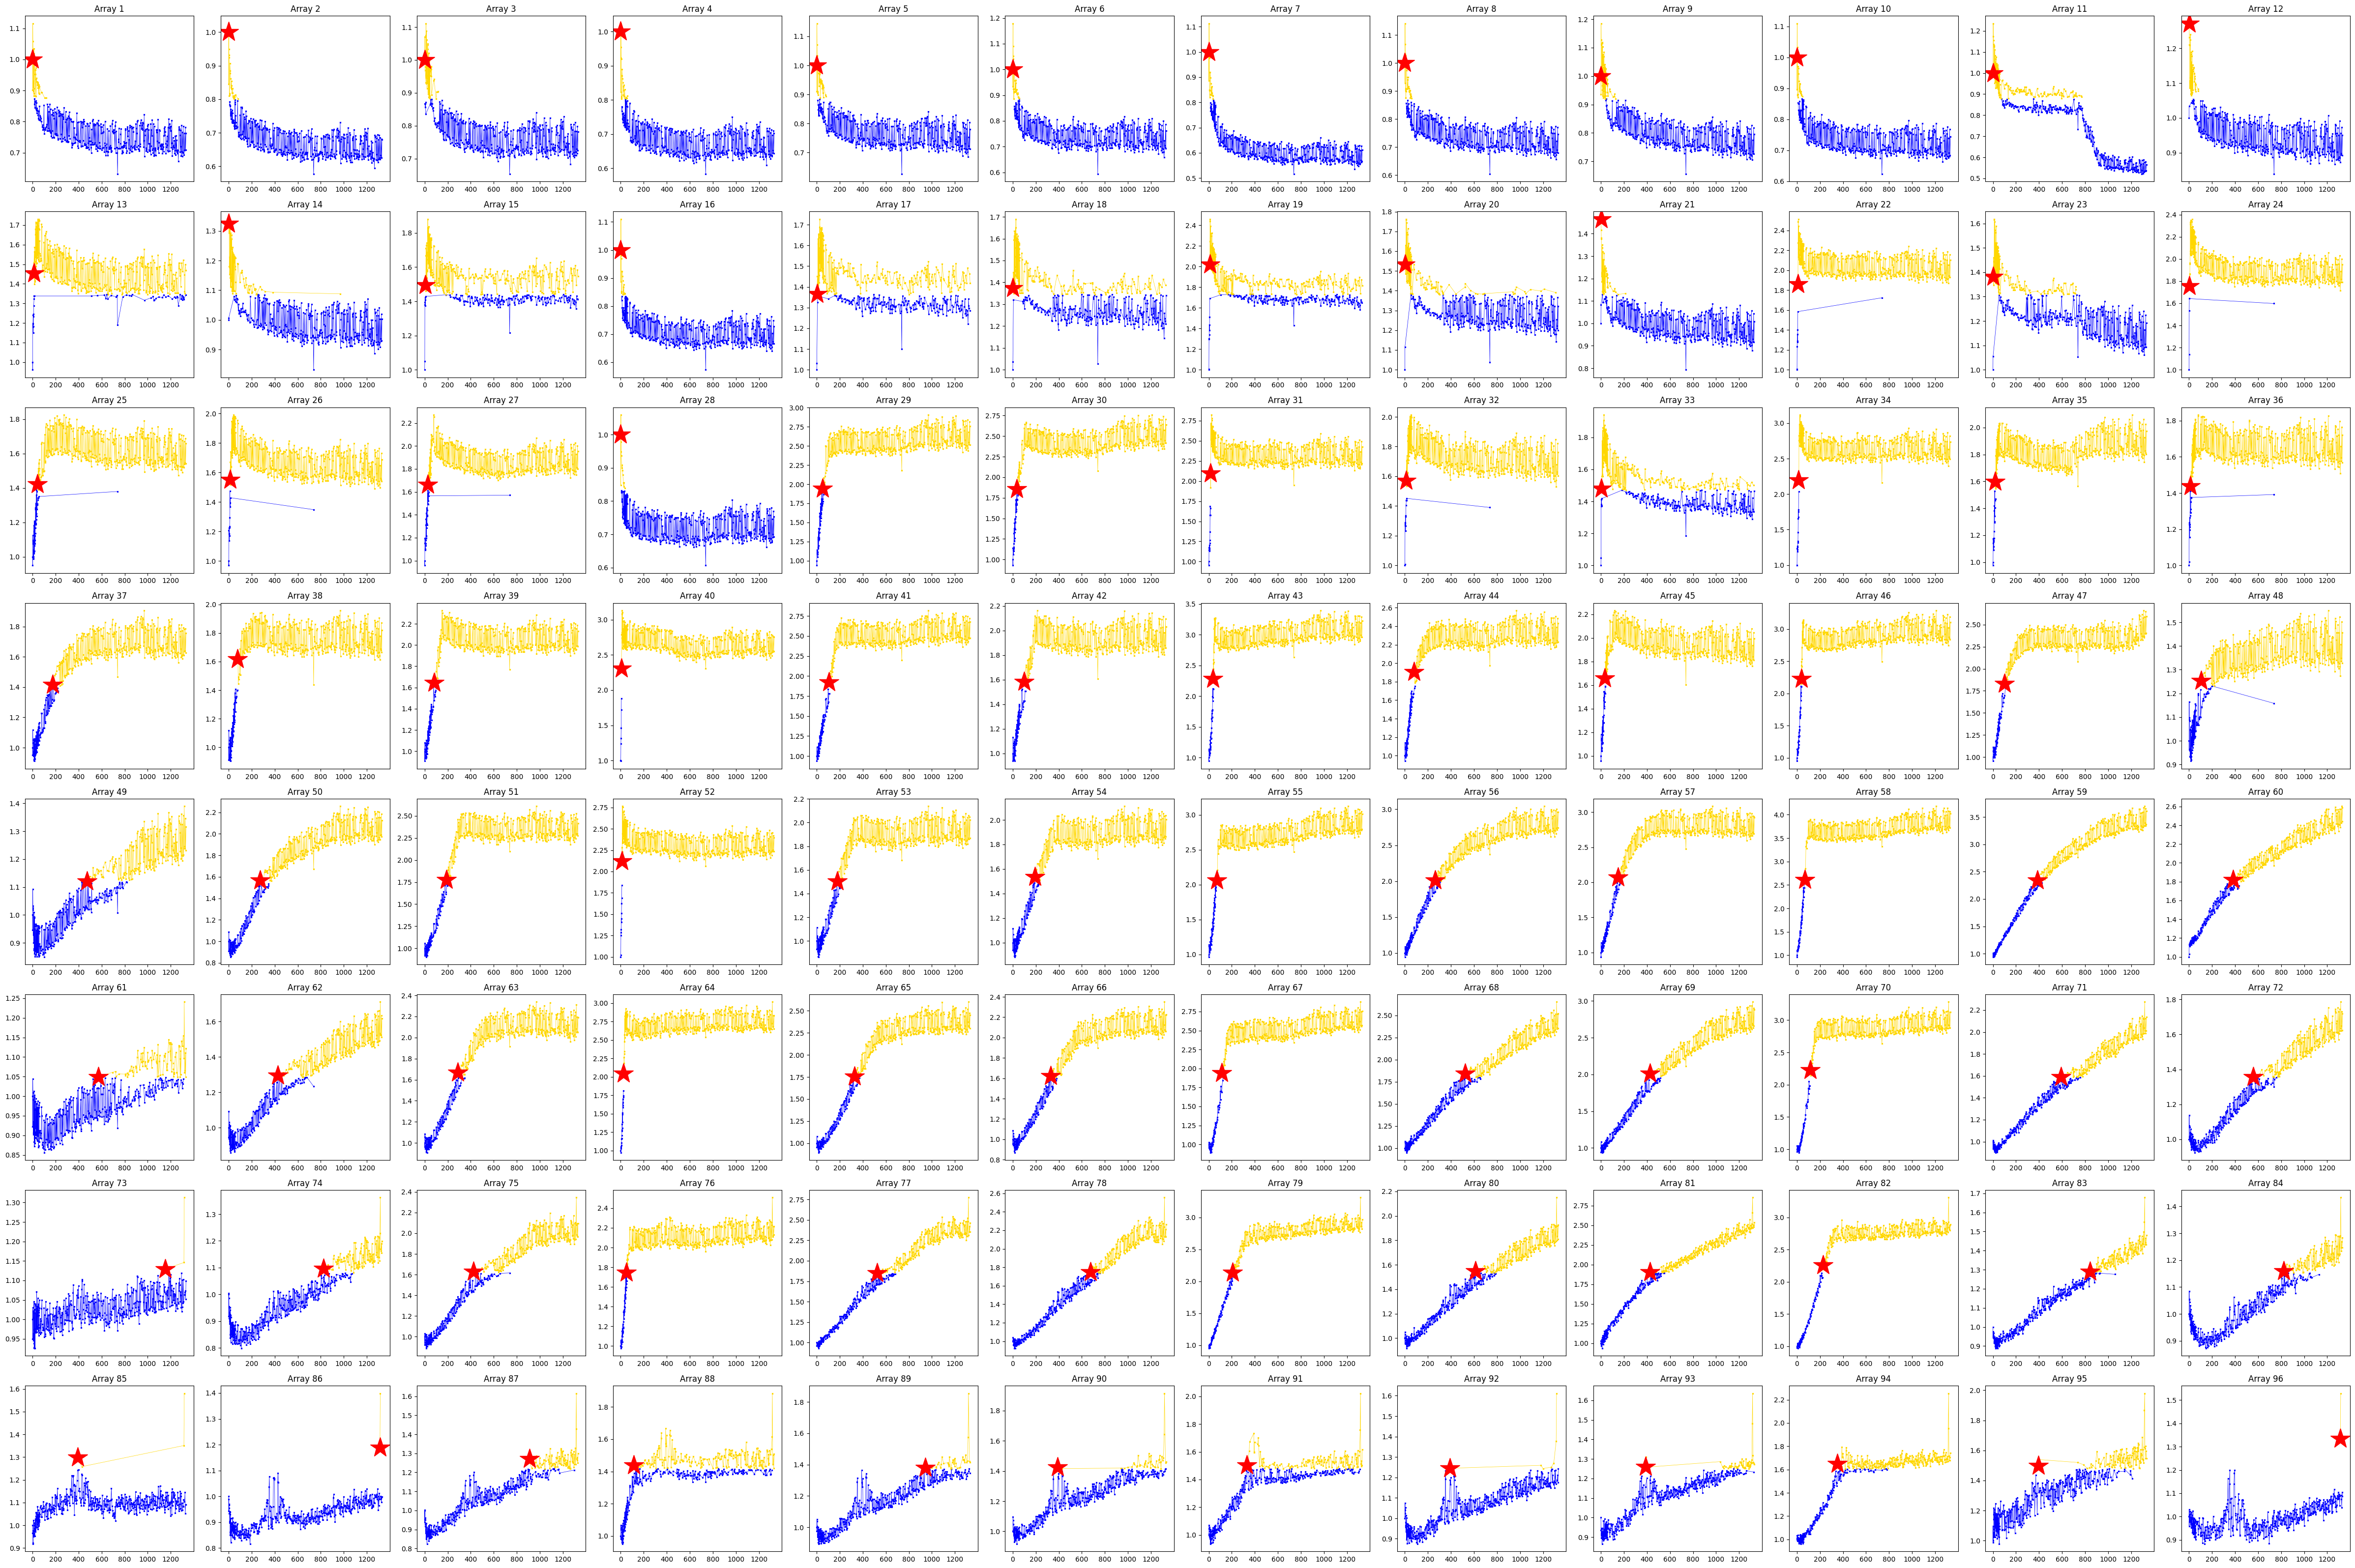

In [2]:
#This bit of code will find the inflection point by taking the max intensity measured per well, subtracting the min intensity per well, and finding the average of that value. 
#This value is then added to the minimum value to determine the "halfway" point between blue (low RGB) and yellow (high RGB), and the time when the intensity crosses this 
#threshold is chosed as the half-life of the reaction in question as the concentration corresponding to that row. 

inflection_points = []
def process(array):
    array_max = max(array)
    array_min = min(array)
    infl_point = array_min + ((array_max - array_min) * 0.5) #Change this if you want to use a different fraction of the max-min range as your inflection point

    greater_than_array = np.where(array >= infl_point)
    time_at_inflection = greater_than_array[0][0]
    array_2_x = time_array[greater_than_array]
    array_2_y = array[greater_than_array]
    inflection_points.append(round(array_2_x[0]))

    less_than_array = np.where(array < infl_point)
    array_1_x = time_array[less_than_array]
    array_1_y = array[less_than_array]

    return array_1_x, array_1_y, array_2_x, array_2_y

intensity_arrays = my_df.iloc[9:105, 7:].to_numpy()

# Initialize a figure with 8 rows and 12 columns
fig, axs = plt.subplots(8, 12, figsize=(48, 32))

# Plot all 96 arrays
for i, array in enumerate(intensity_arrays):
    ax = axs[i // 12, i % 12]
    array_1_x, array_1_y, array_2_x, array_2_y = process(array)
    ax.plot(array_1_x, array_1_y, marker='x', lw=0.5, ms=2.0, color="blue")
    ax.plot(array_2_x, array_2_y, marker='x', lw=0.5, ms=2.0, color="gold")
    ax.plot(array_2_x[0], array_2_y[0],
            marker='*', lw=0.5, ms=30, color="red")
    ax.set_title(f"Array {i+1}")

# Hide empty subplots
for i in range(96, 96):
    axs[i // 12, i % 12].axis('off')

plt.tight_layout()
#plt.savefig(r"E:\Image Analysis\Amide Bond formation\plots.png", dpi=300)
plt.show()

In [3]:
#This section arranges the half-life values into a dataframe.

row_arrays = np.array_split(inflection_points,8)
new_arrays = []
for entry in row_arrays:
    new_arrays.append(np.array_split(entry,2))
array_points = np.array(row_arrays)
df_points = []
df_points = pd.DataFrame(array_points)
df_points

,0,1,2,3,4,5,6,7,8,9,10,11
0,0,0,0,0,0,0,0,0,0,0,0,2
1,11,2,5,0,2,2,9,2,2,9,2,4
2,40,12,27,0,49,35,15,11,5,15,18,12
3,174,78,81,7,105,99,37,78,33,37,99,105
4,474,273,189,11,180,192,69,261,150,69,384,384
5,570,426,288,25,327,330,114,525,426,114,591,558
6,1152,822,426,49,525,675,207,612,426,225,843,822
7,393,1314,909,114,942,390,330,390,390,351,393,1314


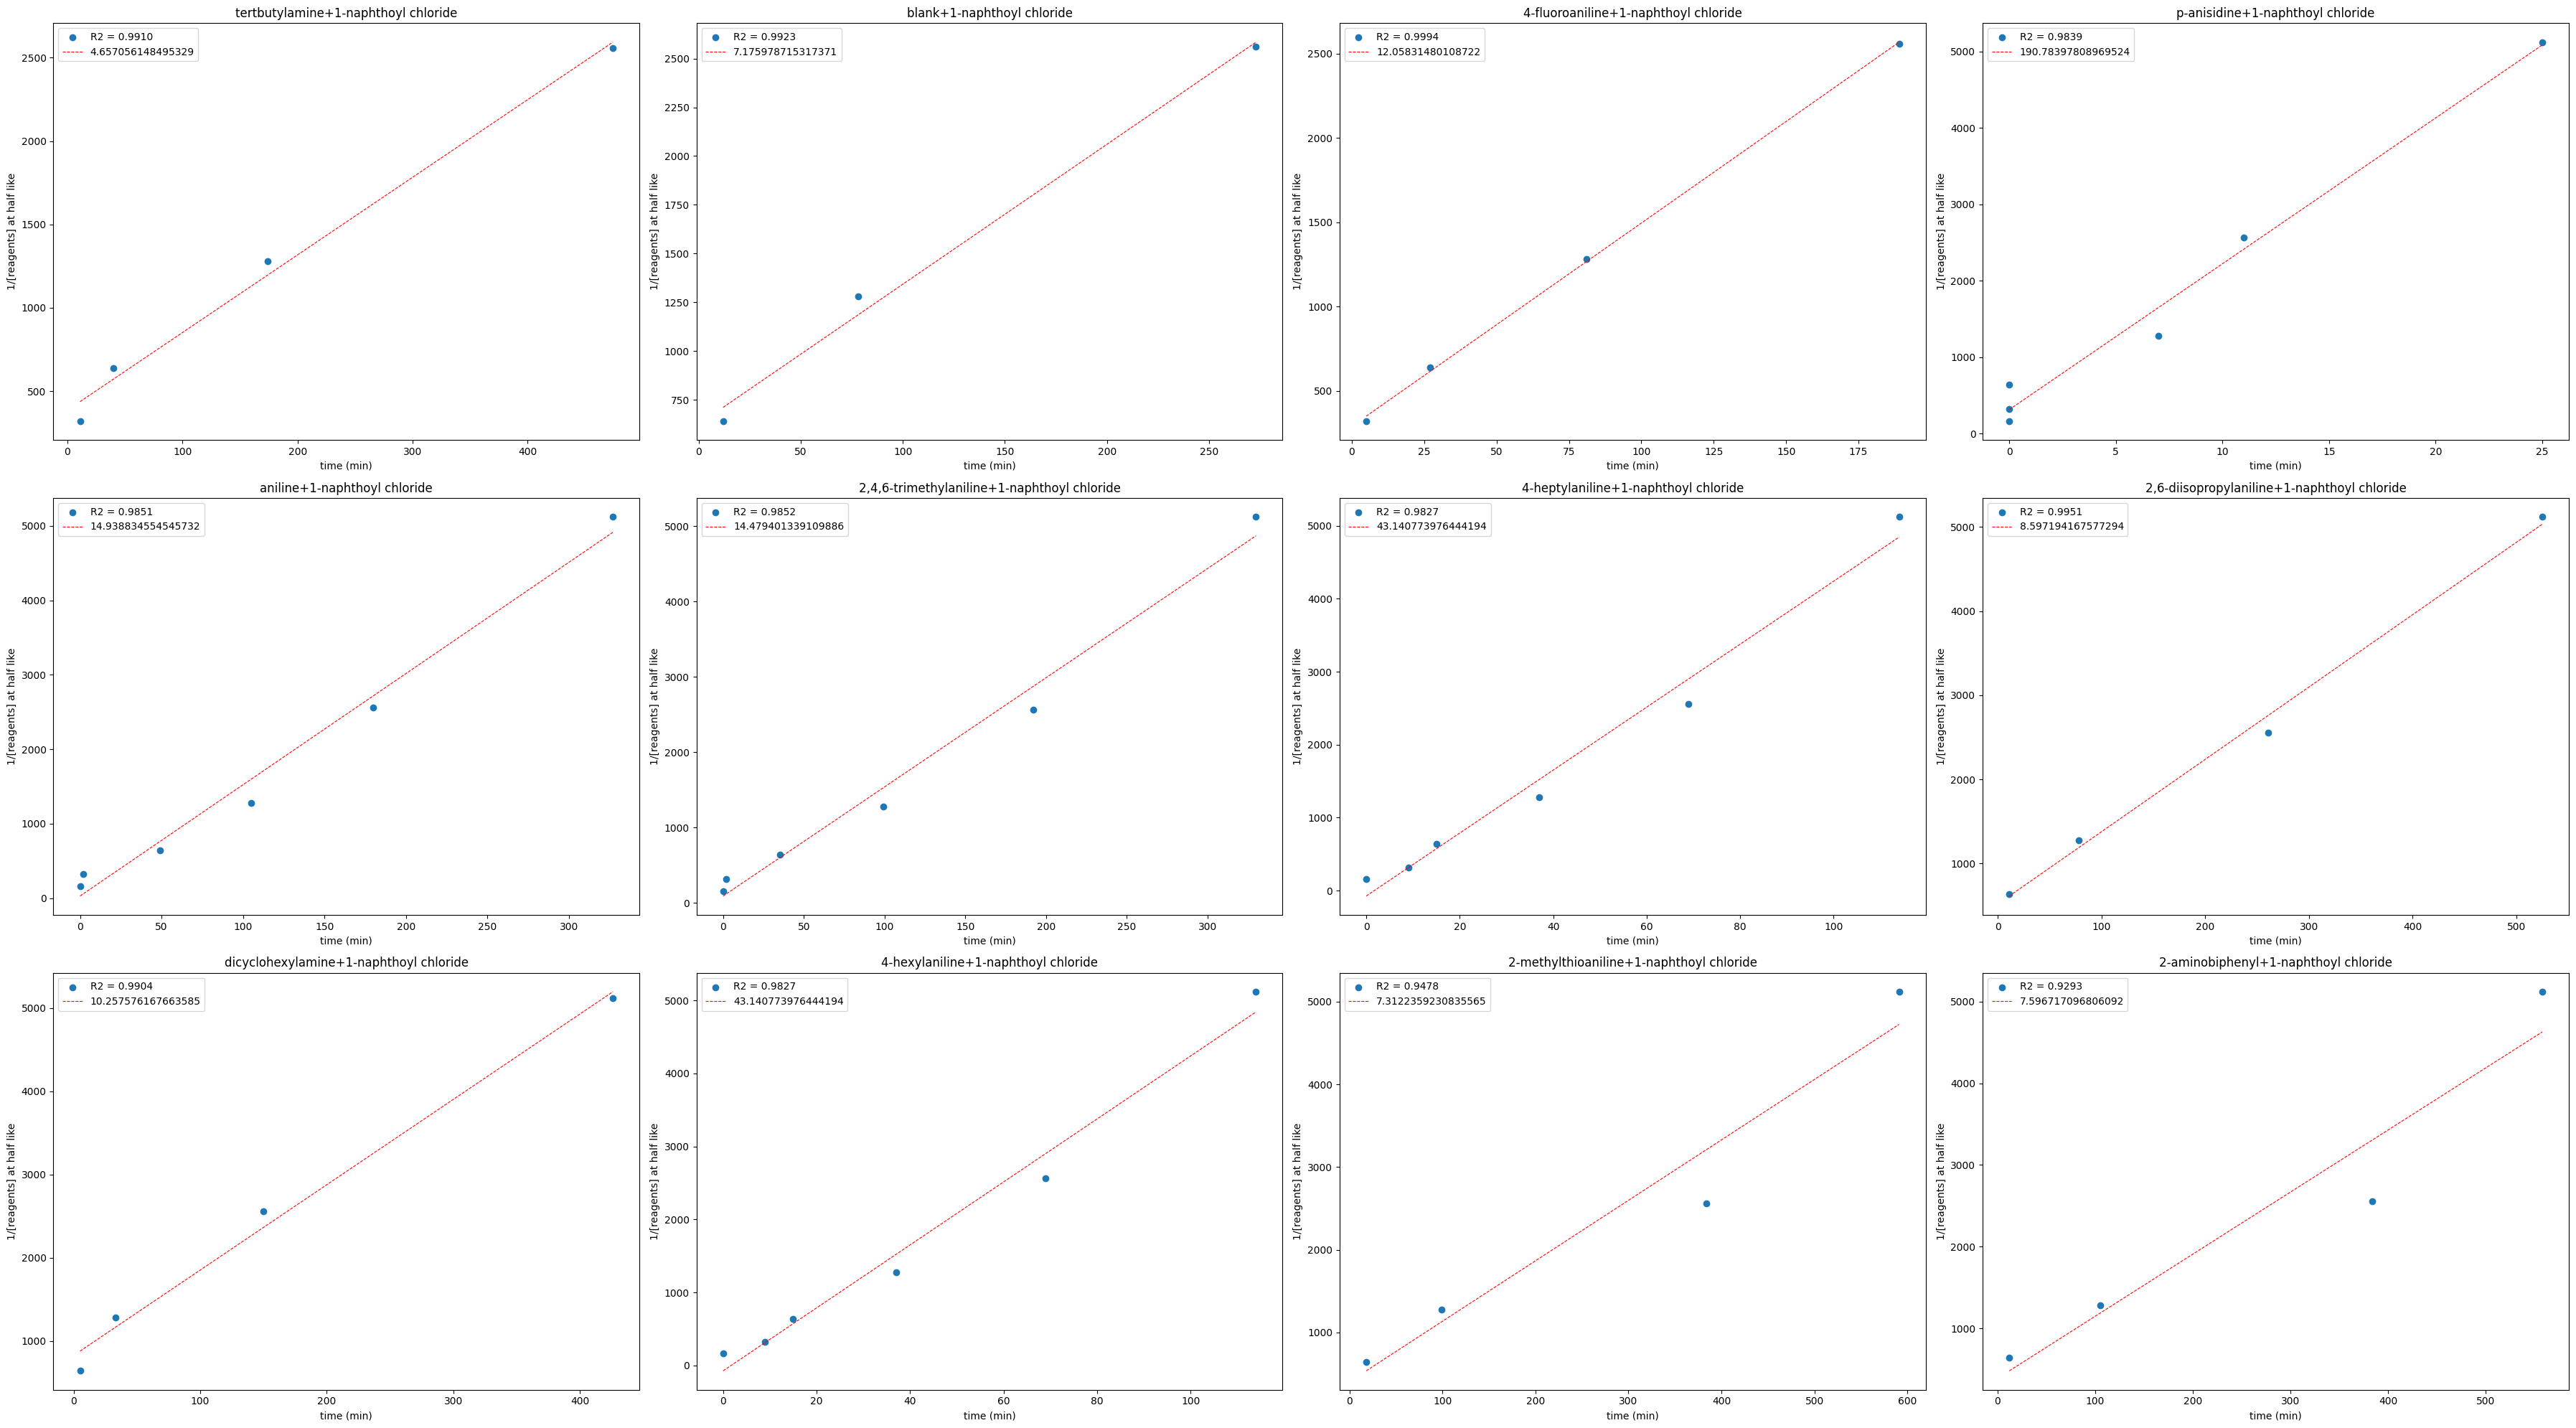

In [5]:
#This section will take the half-life times and, using the concentration of the reagents at the half-life, generate second-order kinetics plots.
#The user will need to alter the "plot_ranges" variable to match the wells that reacted during the course of the experiment. 
# The default range is (0,8). This will include all points. Adjust based on which wells reacted. 

from sklearn.metrics import r2_score


# Specify start and end indices for each reaction
plot_ranges = [(1,5), (2, 5), (1,5), (0,6),(0,6), (0, 6), (0,6), (2,6), (2,6), (0, 6), (2,6), (2,6)]

reg_coefs = []

def array_plot_with_r2(X, y, i, start_idx, end_idx, ax):
    # Slice X and y based on start and end indices
    X_slice = X[start_idx:end_idx]
    y_slice = y[start_idx:end_idx]

    # Fit a linear regression model
    reg = LinearRegression().fit(X_slice.values.reshape(-1, 1), y_slice)

    # Predict Y values using the linear regression model
    y_pred = reg.predict(X_slice.values.reshape(-1, 1))

    # Calculate R^2 value
    r2 = r2_score(y_slice, y_pred)

    # Create scatter plot
    ax.scatter(X_slice, y_slice, label=f'R2 = {r2:.4f}')
    ax.plot(X_slice, y_pred, color='red', linestyle='--', lw=0.8,label= reg.coef_[0])
    reg_coefs.append(reg.coef_[0])

    # Customize plot
    ax.set_xlabel('time (min)')
    ax.set_ylabel('1/[reagents] at half like')
    ax.set_title(str(amine_group[i]) + "+" + str(acid_chloride[0]))
    ax.legend()

# Create a 4x3 grid of plots
fig, axs = plt.subplots(3, 4, figsize=(36, 20))

for i, (start, end) in enumerate(plot_ranges):
    row, col = divmod(i, 4)
    array_plot_with_r2(df_points[i], oneOverA, i, start, end, axs[row, col])

plt.tight_layout()
plt.show()

In [5]:
#This well will organize the rate plot data into a Pandas dataframe

df = pd.DataFrame(index = reagent_stock_concs)
for i in range(12):
    output_list = [""]*8
    output_times = [""]*8
    output_list[plot_ranges[i][0]:plot_ranges[i][1]] = df_points[i][plot_ranges[i][0]:plot_ranges[i][1]].tolist()
    output_times[plot_ranges[i][0]:plot_ranges[i][1]] = oneOverA[plot_ranges[i][0]:plot_ranges[i][1]]
    df[(str(amine_group[i])+ "+" + str(acid_chloride[0])+" times")] = output_list
    df[(str(amine_group[i])+ "+" + str(acid_chloride[0])+" 1/[A]")] = output_times
df

,tertbutylamine+1-naphthoyl chloride times,tertbutylamine+1-naphthoyl chloride 1/[A],blank+1-naphthoyl chloride times,blank+1-naphthoyl chloride 1/[A],4-fluoroaniline+1-naphthoyl chloride times,4-fluoroaniline+1-naphthoyl chloride 1/[A],p-anisidine+1-naphthoyl chloride times,p-anisidine+1-naphthoyl chloride 1/[A],aniline+1-naphthoyl chloride times,aniline+1-naphthoyl chloride 1/[A],...,"2,6-diisopropylaniline+1-naphthoyl chloride times","2,6-diisopropylaniline+1-naphthoyl chloride 1/[A]",dicyclohexylamine+1-naphthoyl chloride times,dicyclohexylamine+1-naphthoyl chloride 1/[A],4-hexylaniline+1-naphthoyl chloride times,4-hexylaniline+1-naphthoyl chloride 1/[A],2-methylthioaniline+1-naphthoyl chloride times,2-methylthioaniline+1-naphthoyl chloride 1/[A],2-aminobiphenyl+1-naphthoyl chloride times,2-aminobiphenyl+1-naphthoyl chloride 1/[A]
50.000,,,,,,,,,0,160,...,,,,,0,160,,,,
25.000,11,320,,,5,320,,,2,320,...,,,,,9,320,,,,
12.500,40,640,12,640,27,640,0,640,49,640,...,11,640,5,640,15,640,18,640,12,640
6.250,174,1280,78,1280,81,1280,7,1280,105,1280,...,78,1280,33,1280,37,1280,99,1280,105,1280
3.125,474,2560,273,2560,189,2560,11,2560,180,2560,...,261,2560,150,2560,69,2560,384,2560,384,2560
1.563,,,,,,,25,5120,327,5120,...,525,5120,426,5120,114,5120,591,5120,558,5120
0.781,,,,,,,,,,,...,,,,,,,,,,
0.391,,,,,,,,,,,...,,,,,,,,,,


In [7]:
#Export the Pandas dataframe as an excel document 

df.to_excel(df_filepath)

In [6]:
#This cell takes the rates calculated from the rate plot data saved above and saves the rates in a Pandas dataframe

row_index = acid_chloride
rates_df = pd.DataFrame(index = row_index)
for i in range(12):
    rates_df[str(amine_group[i])] = reg_coefs[i]
rates_df

,tertbutylamine,blank,4-fluoroaniline,p-anisidine,aniline,"2,4,6-trimethylaniline",4-heptylaniline,"2,6-diisopropylaniline",dicyclohexylamine,4-hexylaniline,2-methylthioaniline,2-aminobiphenyl
1-naphthoyl chloride,4.657056,7.175979,12.058315,186.08565,14.938835,14.479401,43.140774,8.597194,10.257576,43.140774,7.312236,7.596717


In [ ]:
#export the data to excel 

rates_df.to_excel(rate_filepath)